# Interannual variability of passive tracers

This script produces a figure with maps of interannual variability of four AABW tracers

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import PathPatch

import xarray as xr
import numpy as np
import matplotlib as mpl
from matplotlib import gridspec
import matplotlib.path as mpath
import matplotlib.colors as mcolors

from matplotlib import ticker, cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.ticker as mticker
import cmocean.cm 
import intake 
import dask.distributed as dask
import cmcrameri
import xrft
import sys
sys.path.append("/g/data/x77/ps7863/python_scripts/AABW_variability/")
import helper_funcs as helper

In [24]:
import cartopy 
print(cartopy.__version__)

0.25.0


In [2]:
from os import environ
environ["PYTHONWARNINGS"] = "ignore"

In [3]:
client = dask.Client(threads_per_worker = 1)
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 24
Total threads: 24,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39677,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37695,Total threads: 1
Dashboard: /proxy/42583/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:41153,


In [4]:
# lon_slice = slice(80-360, 190-360)
lat_slice = slice(-82, -55)

degree =  u'\N{DEGREE SIGN}'

In [5]:
figdir = '/g/data/x77/ps7863/figures/AABW_variability/bottom_500m/'
iaf_cycle3 = '01deg_jra55v140_iaf_cycle3'
catalog = intake.cat.access_nri

In [6]:
datastore = catalog[iaf_cycle3].search(variable='ht')
datastore = datastore.search(path=datastore.df.loc[0,'path'])
dataset = datastore.to_dask(xarray_open_kwargs = {"decode_timedelta" : True })
dataset = dataset.squeeze()

ht = dataset['ht']
land = xr.where(np.isnan(ht.rename('land')), 1, np.nan)

In [7]:
# To plot 1000-m contour
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf[np.where(shelf!=0)] = np.nan
shelf = shelf+1
shelf = np.nan_to_num(shelf)
shelf = xr.DataArray(shelf, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

In [8]:
outpath = '/g/data/x77/ps7863/data/swmt/'

In [9]:
def get_SWMT(outpath):
    # net_transformation = xr.open_dataset(outpath + '/SWMT_' + time_bounds + '_adelie.nc', chunks={'isopycnal_bins':1})
    # net_transformation = net_transformation.surface_water_mass_transformation
    heat_transformation = xr.open_mfdataset(outpath + 'binned_heat_transformation_mom5_*.nc', chunks={'isopycnal_bins':1},combine='nested', concat_dim='time')
    heat_transformation = heat_transformation.heat_transformation
    salt_transformation = xr.open_mfdataset(outpath + '/binned_salt_transformation_mom5_*.nc', chunks={'isopycnal_bins':1},combine='nested', concat_dim='time')
    salt_transformation = salt_transformation.salt_transformation
    return heat_transformation, salt_transformation # net_transformation 

In [10]:
swmt_heat, swmt_salt = get_SWMT(outpath)
swmt_net = swmt_heat + swmt_salt

In [11]:
weddell_transformation_density = 37.355

weddell_subduction_plot = swmt_net.sel(isopycnal_bins = weddell_transformation_density, method='nearest') * 1e4
weddell_swmt_xt =weddell_subduction_plot.xt_ocean
weddell_swmt_yt = weddell_subduction_plot.yt_ocean

In [12]:
ross_transformation_density = 37.39
ross_subduction_plot = swmt_net.sel(isopycnal_bins=ross_transformation_density, method='nearest') * 1e4
# ross_subduction_plot = ross_subduction_plot * ross_mask
ross_subduction_plot = ross_subduction_plot.sortby(ross_subduction_plot.xt_ocean)

In [13]:
eastAA_transformation_density = 37.27
eastAA_subduction_plot = swmt_net.sel(isopycnal_bins=eastAA_transformation_density, method='nearest') * 1e4
eastAA_subduction_plot = eastAA_subduction_plot.sortby(eastAA_subduction_plot.xt_ocean)


In [14]:
wsbw = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/wsbw_iav_std.nc')
rsbw = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/rsbw_iav_std.nc')
albw = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/albw_iav_std.nc')
cdbw = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/pbbw_iav_std.nc')
wsbw = wsbw['wsbw_iav_std']
rsbw = rsbw['rsbw_iav_std']
albw = albw['albw_iav_std']
cdbw = cdbw['pbbw_iav_std']

In [17]:
theta  = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.45
verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)


In [15]:
prydz_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/prydz_tracer_mask.nc')
adelie_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/adelie_tracer_mask.nc') 
weddell_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/weddell_tracer_mask.nc')  
ross_mask = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/ross_tracer_mask.nc')   
prydz_mask = prydz_mask['Prydz tracer mask']
adelie_mask = adelie_mask['Adelie tracer mask']
ross_mask = ross_mask['Ross tracer mask'] 
weddell_mask = weddell_mask['Weddell tracer mask']

In [16]:
levels_tracer = np.arange(0, 0.17, 0.01)
cmap_tracer = cmcrameri.cm.tofino
cmap_swmt = cmcrameri.cm.hawaii_r
norm_swmt = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.25, vmax=0.5)
fontsize = 10

# Circumpolar maps 

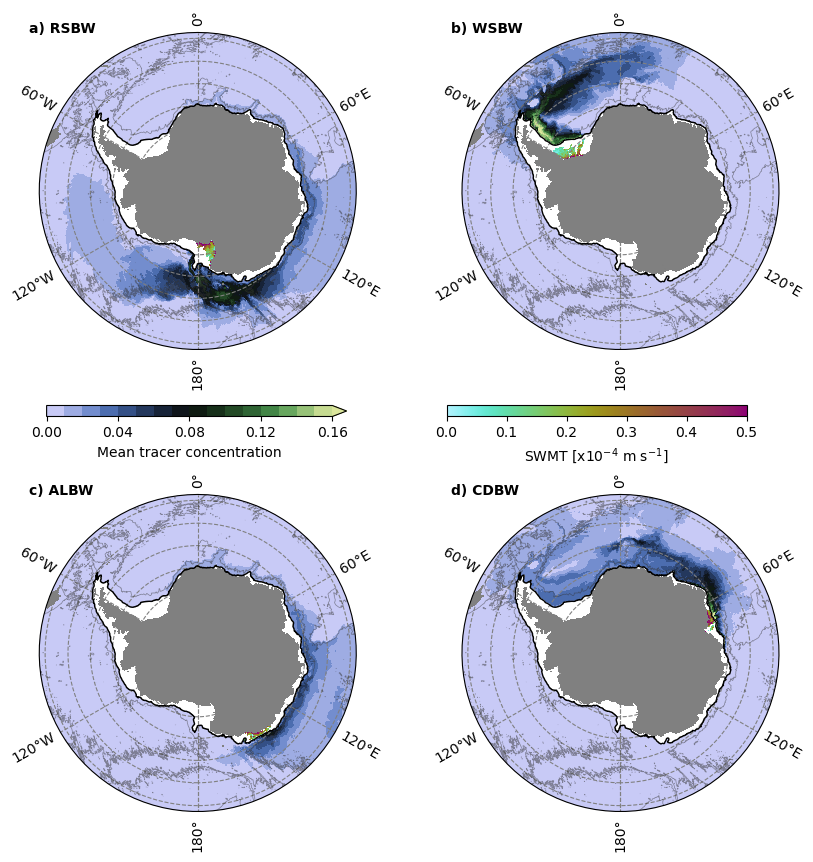

In [22]:
fig = plt.figure(4, figsize=(10, 11))
map_proj = ccrs.SouthPolarStereo()
map_proj._threshold /= 300.

ax1 = plt.subplot(2, 2, 1, projection=map_proj, facecolor='grey')
ax2 = plt.subplot(2, 2, 2, projection=map_proj, facecolor='grey')
ax3 = plt.subplot(2, 2, 3, projection=map_proj, facecolor='grey')
ax4 = plt.subplot(2, 2, 4, projection=map_proj, facecolor='grey')

for ax, label in zip([ax1, ax2, ax3, ax4], ['a) RSBW', 'b) WSBW', 'c) ALBW', 'd) CDBW']):
    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    gl=ax.gridlines(draw_labels=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    ax.spines['geo'].set_visible(True)
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.ylocator = LatitudeLocator()
    gl.xlocator = LongitudeLocator()
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    ax.annotate(label, xy=(0, 1), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',
            fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif', fontweight='semibold') 
    # Filled land 
    land.plot.contourf(ax=ax, colors='grey',
                       zorder=0.7,
                       transform=ccrs.PlateCarree(),
                       add_colorbar=False)
    
    # Depth contours
    ht.plot.contour(ax=ax, levels=[3500],
                    colors='0.2', linewidths=[0.5, 2, 0.5, 0.5], alpha=0.5,
                    transform=ccrs.PlateCarree())
    
    # SHELF MASK
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white', zorder=0.6)
    
    # SHELFBREAK contour
    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
            [0.5],
            colors = 'k',
            linewidths = 1,
            transform=ccrs.PlateCarree())

cf1 = ax1.contourf(rsbw.xt_ocean, rsbw.yt_ocean, rsbw*2, cmap=cmap_tracer, levels=levels_tracer, transform=ccrs.PlateCarree(), extend='max', zorder=0.5)
cf2 = ax2.contourf(wsbw.xt_ocean, wsbw.yt_ocean, wsbw*2, cmap=cmap_tracer, levels=levels_tracer, transform=ccrs.PlateCarree(), extend='max', zorder=0.5)
cf3 = ax3.contourf(albw.xt_ocean, albw.yt_ocean, albw*2, cmap=cmap_tracer, levels=levels_tracer, transform=ccrs.PlateCarree(), extend='max', zorder=0.5)
cf4 = ax4.contourf(cdbw.xt_ocean, cdbw.yt_ocean, cdbw*2, cmap=cmap_tracer, levels=levels_tracer, transform=ccrs.PlateCarree(), extend='max', zorder=0.5)


pc2=(ross_subduction_plot*ross_mask).mean('time').plot.pcolormesh(
        ax=ax1,
        norm=norm_swmt,
        transform=ccrs.PlateCarree(), 
        cmap=cmap_swmt, 
        add_colorbar=False, 
        zorder=0.8
        )
(weddell_subduction_plot*weddell_mask).mean('time').plot.pcolormesh(
        ax=ax2,
        norm=norm_swmt,
        transform=ccrs.PlateCarree(), 
        cmap=cmap_swmt,
        add_colorbar=False, 
        zorder=0.8
        )

(eastAA_subduction_plot*adelie_mask).mean('time').plot.pcolormesh( 
        ax=ax3,
        norm=norm_swmt,
        transform=ccrs.PlateCarree(),
        cmap=cmap_swmt,
        add_colorbar=False, 
        zorder=0.8
        )
(eastAA_subduction_plot*prydz_mask).mean('time').plot.pcolormesh(
        ax=ax4,
        norm=norm_swmt,
        transform=ccrs.PlateCarree(),
        cmap=cmap_swmt,
        add_colorbar=False, 
        zorder=0.8
        )

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_title('')

cbar_ax1 = fig.add_axes([0.15, 0.5, 0.3, 0.01])  # [left, bottom, width, height]
cbar_ax2 = fig.add_axes([0.55, 0.5, 0.3, 0.01])

cbar1 = plt.colorbar(cf1, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.04, 0.08, 0.12, 0.16],
                     location='bottom'
                    )
cbar2 = plt.colorbar(pc2, cax=cbar_ax2,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
                     location='bottom'
                    )
cbar1.set_label(r'\sigma', fontsize=10)
cbar2.set_label(r'SWMT [x10$^{-4}$ m s$^{-1}$]', fontsize=10)



plt.savefig(f'{figdir}/AABW_circumpolar_tracer_iav_1968-2018.png', dpi=300)

In [17]:
xt_ocean = ht.xt_ocean
yt_ocean = ht.yt_ocean

In [18]:
X, Y = np.meshgrid(xt_ocean, yt_ocean)
X = xr.DataArray(X, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])
Y = xr.DataArray(Y, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])

In [19]:
def make_boundary_path(longitudes, latitudes):
    """
    Return a path around boundary to create a sector map, then cut it out given
    longitudes and latitudes.
    """

    boundary_path = np.array([longitudes[-1, :], latitudes[-1, :]])
    boundary_path = np.append(
        boundary_path, np.array([longitudes[::-1, -1], latitudes[::-1, -1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[1, ::-1], latitudes[1, ::-1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[:, 1], latitudes[:, 1]]), axis=1
    )
    boundary_path = mpath.Path(np.swapaxes(boundary_path, 0, 1))

    return boundary_path

In [20]:
# Function to create individual subplots
def create_subplot(gs_position, projection, minlon, maxlon, minlat, maxlat):

    ax = fig.add_subplot(gs[gs_position], projection=projection)
    ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    
    # Select data for the current subplot
    lons = X.sel({"xt_ocean": slice(minlon, maxlon), "yt_ocean": slice(minlat, maxlat)})
    lats = Y.sel({"xt_ocean": slice(minlon, maxlon), "yt_ocean": slice(minlat, maxlat)})
    
    # Generate boundary path
    boundary_path = make_boundary_path(lons, lats)
    ax.set_boundary(boundary_path, transform=ccrs.PlateCarree())  
    ax.add_patch(PathPatch(boundary_path, transform=ccrs.PlateCarree(), fc='none', ec='black', lw=1.5))
    ax.spines['geo'].set_visible(True) 
    # gl = ax.gridlines(draw_labels=True, dms=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    # gl.xformatter = LongitudeFormatter()
    # gl.yformatter = LatitudeFormatter()
    # gl.ylocator = mticker.FixedLocator([-75, -70, -65, -60, -55, -50])
    # gl.xlocator = mticker.FixedLocator([-160, -140, -120, -100, -80, -60, -40, -20, 0, 20, 40, 60, 80, 100, 120, 140, 160, 180])
    # gl.xlabels_bottom = False 
    # gl.ylabels_left = False
    # gl.xlabel_style = {'size': 8}
    # gl.ylabel_style = {'size': 8}
    return ax


# Define first projection parameters
midlon1 = 150-360 # 135
maxlon1 = midlon1 + 70
minlon1 = midlon1 - 70
minlat1 = -80
maxlat1 = -50
midlat1 = (minlat1 + maxlat1) / 2

projection1 = ccrs.Stereographic(central_longitude=midlon1, central_latitude=midlat1)

# Define second projection parameters
midlon2 = 5
maxlon2 = midlon2 + 75
minlon2 = midlon2 - 75
minlat2 = -80
maxlat2 = -50
midlat2 = (minlat2 + maxlat2) / 2

projection2 = ccrs.Stereographic(central_longitude=midlon2, central_latitude=midlat2)

# cmap_swmt =  cmcrameri.cm.hawaii_r
# norm_swmt = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.25, vmax=0.5)
# cmap_tracer


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 13.97 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


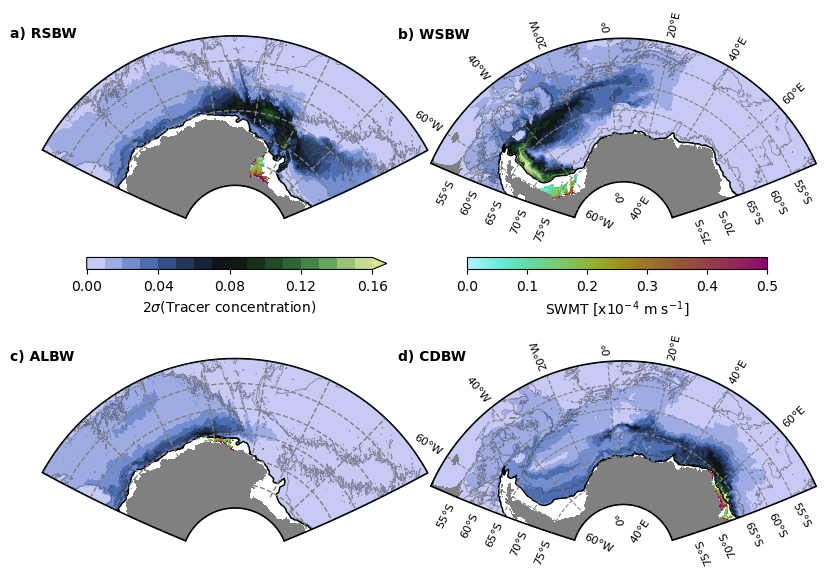

In [27]:
fig = plt.figure(figsize=(10, 8)) #, constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.005, hspace=0.1)  # Adjust subplot spacing



# First subplot (Projection 1)
ax1 = create_subplot((0, 0), projection1, minlon1, maxlon1, minlat1, maxlat1)

# Second subplot (Projection 2)
ax2 = create_subplot((0, 1), projection2, minlon2, maxlon2, minlat2, maxlat2)

# Third subplot (Projection 1)
ax3 = create_subplot((1, 0), projection1, minlon1, maxlon1, minlat1, maxlat1)

# Fourth subplot (Projection 2)
ax4 = create_subplot((1, 1), projection2, minlon2, maxlon2, minlat2, maxlat2)


cf1 = ax1.contourf(rsbw.xt_ocean, rsbw.yt_ocean, rsbw*2, cmap=cmap_tracer, levels=levels_tracer, transform=ccrs.PlateCarree(), extend='max', zorder=0.1)
cf2 = ax2.contourf(wsbw.xt_ocean, wsbw.yt_ocean, wsbw*2, cmap=cmap_tracer, levels=levels_tracer, transform=ccrs.PlateCarree(), extend='max', zorder=0.1)
cf3 = ax3.contourf(albw.xt_ocean, albw.yt_ocean, albw*2, cmap=cmap_tracer, levels=levels_tracer, transform=ccrs.PlateCarree(), extend='max', zorder=0.1)
cf4 = ax4.contourf(cdbw.xt_ocean, cdbw.yt_ocean, cdbw*2, cmap=cmap_tracer, levels=levels_tracer, transform=ccrs.PlateCarree(), extend='max', zorder=0.1)



for ax in [ax1, ax2, ax3, ax4]:
    # 3500 isobath
    ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
                levels=[3500],
                colors='0.2',
                linewidths=[0.5, 2, 0.5, 0.5],
                alpha=0.5,
                transform=ccrs.PlateCarree())
    # SHELFBREAK
    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1,
                transform=ccrs.PlateCarree())
    # SHELF FILLED CONTOUR
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf,
                [0.5, 1],
                transform=ccrs.PlateCarree(),
                colors='white',
                zorder=0.2
               )
    # LAND
    ax.contourf(land.xt_ocean, land.yt_ocean, land,
             transform=ccrs.PlateCarree(),
             colors='grey', 
                zorder=0.3
            )


#SWMT 
pc=(ross_subduction_plot*ross_mask).mean('time').plot.pcolormesh(
            ax=ax1,
            norm=norm_swmt,
            transform=ccrs.PlateCarree(), 
            cmap=cmap_swmt, 
            add_colorbar=False, 
            zorder=0.4
            )
(weddell_subduction_plot*weddell_mask).mean('time').plot.pcolormesh(
            ax=ax2,
            norm=norm_swmt,
            transform=ccrs.PlateCarree(), 
            cmap=cmap_swmt,
            add_colorbar=False, 
            zorder=0.4
            )

(eastAA_subduction_plot*adelie_mask).mean('time').plot.pcolormesh( 
            ax=ax3,
            norm=norm_swmt,
            transform=ccrs.PlateCarree(),
            cmap=cmap_swmt,
            add_colorbar=False, 
            zorder=0.4
            )
(eastAA_subduction_plot*prydz_mask).mean('time').plot.pcolormesh(
            ax=ax4,
            norm=norm_swmt,
            transform=ccrs.PlateCarree(),
            cmap=cmap_swmt,
            add_colorbar=False, 
            zorder=0.4
            )


lats = [-50, -55, -60, -65, -70, -75]
lons = [100, 120, 140, 160, 180, 200]

for ax in [ax1, ax3]:
    for lat in lats:
        ax.plot(np.arange(-280, -140, 0.01), np.full_like(np.arange(-280, -140, 0.01), lat), transform=ccrs.PlateCarree(), linestyle='--', color='grey', linewidth=1, zorder=2)
    for lon in lons:
        ax.plot(np.full_like(np.arange(-76, -50, 0.01), lon), np.arange(-76, -50, 0.01), transform=ccrs.PlateCarree(), linestyle='--', color='grey', linewidth=1, zorder=2)

for ax in [ax2, ax4]:
    gl = ax.gridlines(draw_labels=True, dms=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.ylocator = mticker.FixedLocator([-75, -70, -65, -60, -55, -50])
    gl.xlocator = mticker.FixedLocator([-60, -40, -20, 0, 20, 40, 60, 80])
    gl.labels_bottom = False 
    gl.labels_left = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

# vertical cbars on the left
cbar_ax1 = fig.add_axes([0.17, 0.52, 0.3, 0.015])  # [left, bottom, width, height]
cbar_ax2 = fig.add_axes([0.55, 0.52, 0.3, 0.015])  # under the first colobar

cbar1 = plt.colorbar(cf1, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.04, 0.08, 0.12, 0.16],
                     location='bottom'
                    )
cbar2 = plt.colorbar(pc, cax=cbar_ax2,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
                     location='bottom'
                    )
cbar1.set_label(r'2$\sigma$(Tracer concentration)', fontsize=10)
cbar2.set_label(r'SWMT [x10$^{-4}$ m s$^{-1}$]', fontsize=10)

for ax, label in zip([ax1, ax2, ax3, ax4], ['a) RSBW', 'b) WSBW', 'c) ALBW', 'd) CDBW']):
    ax.annotate(
        label,
        xy=(-0.1, 1.1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=10, verticalalignment='top', fontfamily='sans-serif',
        fontweight='semibold')
    ax.set_title('')

plt.savefig(f'{figdir}/AABW_tracer_iav_1968-2018.png', dpi=300, bbox_inches='tight')